# Qubit Spectroscopy with QProgram

This notebook demonstrates how to write a qubit spectroscopy experiment using the QProgram DSL.

In spectroscopy, we sweep the drive frequency across a range and measure the readout response to find the qubit's resonance frequency.

In [1]:
import numpy as np

import qprogram as qp
from qprogram.buses import BusSchema
from qprogram.waveforms import IQPair, Square

## 1. Setup bus schema and waveforms

We use a transmon schema — each qubit has `drive` (IQ) and `readout` (IQ, acquires) buses. The schema provides typed, validated bus references like `q[0].drive` instead of raw strings.

In [2]:
# Bus schema for transmon qubits
schema = BusSchema.transmon()
schema = BusSchema.transmon(naming=qp.BusNaming(pattern="{bus_type}_{element}{index}_bus"))
q = schema.q


# Drive pulse
spec_pulse = IQPair(
    I=Square(amplitude=0.05, duration=10_000),  # 10 us, low power
    Q=Square(amplitude=0.0, duration=10_000),
)

# Readout pulse and integration weights
readout_pulse = IQPair(
    I=Square(amplitude=0.5, duration=2_000),  # 2 us readout
    Q=Square(amplitude=0.0, duration=2_000),
)
readout_weights = IQPair(
    I=Square(amplitude=1.0, duration=2_000),
    Q=Square(amplitude=1.0, duration=2_000),
)

## 2. Build the QProgram

Sweep the drive frequency from 4.5 GHz to 5.5 GHz in 1 MHz steps. We reference buses through the schema (`q[0].drive`, `q[0].readout`) which gives us validation — for example, trying to `measure()` on `q[0].drive` would raise a `TypeError` because drive buses don't have an ADC.

Note: the user just writes `set_frequency` with the desired range. The compiler decides whether to use hardware NCO sweeps, software LO reconfiguration, or a combination.

In [3]:
program = qp.QProgram(label="Qubit Spectroscopy", description="Sweep drive frequency to find qubit resonance")

frequency = program.variable("frequency", label="Qubit Frequency", units="Hz")

with program.average(shots=1000):
    with program.for_loop(frequency, start=4.5e9, stop=5.5e9, step=1e6):
        # Set drive frequency for this iteration
        program.set_frequency(q[0].drive, frequency)

        # Play spectroscopy pulse on drive (IQ bus — validated)
        program.play("q[0].drive", spec_pulse)
        program.sync()

        # Measure on readout (has ADC — validated)
        program.measure(q[0].readout, readout_pulse, readout_weights)

## 3. Serialize to .qp format

The program can be saved to a `.qp` file for sharing, version control, or execution on a remote platform.

In [4]:
# Save
qp.save(program, "./spectroscopy.qp")

## 4. Simulate results

Since we don't have a real platform here, let's simulate what `QProgramResult` would look like after execution.

The result is an `xarray.DataArray` with dimensions `(freq, IQ)` — 1001 frequency points, 2 values (I/Q) each.

In [5]:
import xarray as xr

from qprogram.result import QProgramResult

# Simulate: Lorentzian dip at 5.0 GHz
freq_values = np.arange(4.5e9, 5.5e9, 1e6)
f0 = 5.0e9  # qubit frequency
gamma = 10e6  # linewidth

# Lorentzian response
lorentzian = gamma**2 / ((freq_values - f0) ** 2 + gamma**2)
noise = 0.02 * np.random.randn(len(freq_values))

I_data = 1.0 - 0.8 * lorentzian + noise
Q_data = 0.3 * lorentzian + 0.02 * np.random.randn(len(freq_values))

# Build QProgramResult
data = np.stack([I_data, Q_data], axis=-1)  # shape: (1000, 2)

da = xr.DataArray(
    data,
    dims=(frequency.id, "IQ"),
    coords={frequency.id: freq_values, "IQ": ["I", "Q"]},
    attrs={
        "long_name": frequency.label,
        "units": frequency.units,
        "description": frequency.description
    }
)

result = QProgramResult()
result.append_measurement(str(q[0].readout), da)  # use schema bus name

## 5. Analyze results

With xarray, slicing and analysis is natural.

In [6]:
da = result.get(measurement=0)

# Extract I and Q
I = da.sel(IQ="I")
Q = da.sel(IQ="Q")

# Compute amplitude and phase
s21 = I.values + 1j * Q.values
amplitude = np.abs(s21)
phase = np.angle(s21)

# Find qubit frequency (minimum of amplitude)
freq_min_idx = np.argmin(amplitude)
qubit_freq = da.coords["frequency"].values[freq_min_idx]

print(qubit_freq)

5000000000.0


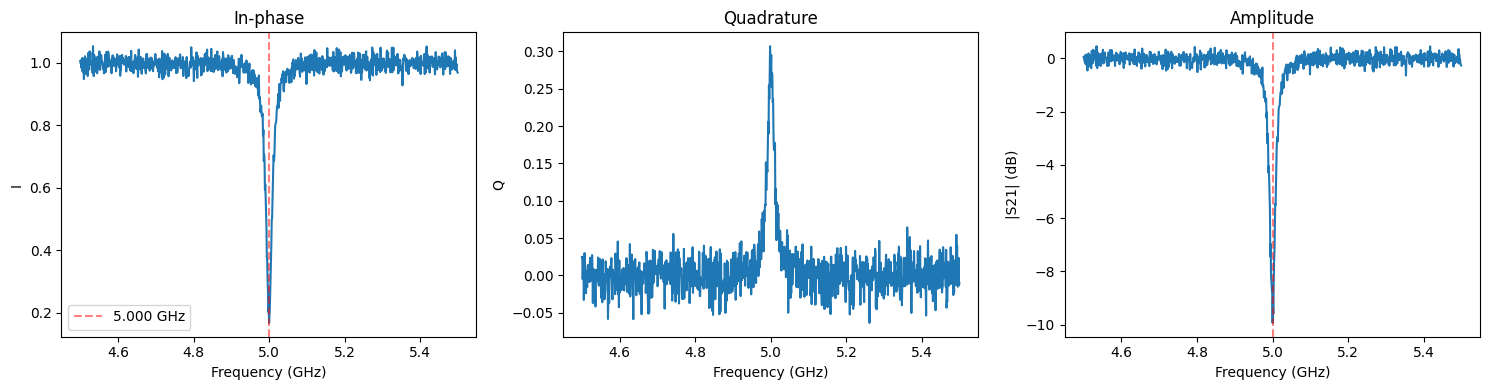

In [7]:
try:
    import matplotlib.pyplot as plt

    freqs_ghz = da.coords["frequency"].values / 1e9

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(freqs_ghz, I.values)
    axes[0].set_xlabel("Frequency (GHz)")
    axes[0].set_ylabel("I")
    axes[0].set_title("In-phase")
    axes[0].axvline(qubit_freq / 1e9, color="r", ls="--", alpha=0.5, label=f"{qubit_freq / 1e9:.3f} GHz")
    axes[0].legend()

    axes[1].plot(freqs_ghz, Q.values)
    axes[1].set_xlabel("Frequency (GHz)")
    axes[1].set_ylabel("Q")
    axes[1].set_title("Quadrature")

    axes[2].plot(freqs_ghz, 20 * np.log10(amplitude))
    axes[2].set_xlabel("Frequency (GHz)")
    axes[2].set_ylabel("|S21| (dB)")
    axes[2].set_title("Amplitude")
    axes[2].axvline(qubit_freq / 1e9, color="r", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()
except ImportError:
    pass

## 6. Save and reload the program

Round-trip through `.qp` file format.

In [8]:
# Save
qp.save(program, "./spectroscopy.qp")

# Load back
loaded = qp.load("./spectroscopy.qp")

In [9]:
print(qp.dumps(loaded))

#!QProgram 1.0

metadata:
  label: "Qubit Spectroscopy"
  description: "Sweep drive frequency to find qubit resonance"

schema:
  bus "drive_q0_bus" type="drive" element="q" index=0 info=IQ
  bus "readout_q0_bus" type="readout" element="q" index=0 info=IQ+acquires

body:
  var frequency label="Qubit Frequency" units="Hz"

  average 1000:
    for frequency in range(4500000000.0, 5500000000.0, 1000000.0):
      set_frequency "drive_q0_bus" frequency
      play "q[0].drive" IQPair(I=Square(amplitude=0.05, duration=10000), Q=Square(amplitude=0.0, duration=10000))
      sync
      measure "readout_q0_bus" IQPair(I=Square(amplitude=0.5, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))



In [10]:
for x in loaded.buses:
    print(type(x))

<class 'qprogram.buses.BusRef'>
<class 'qprogram.buses.BusRef'>
<class 'str'>
